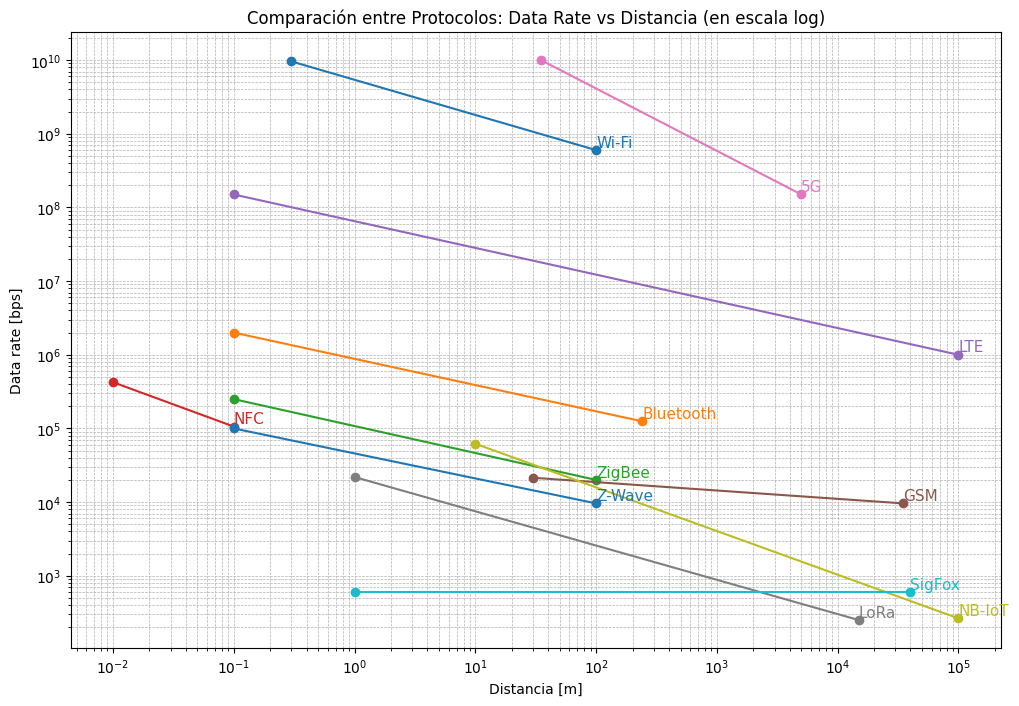

Tabla de distancias y data rate (mínimos y máximos) en notación ingenieril:


,Protocolo,Distancia_min_m,Distancia_max_m,DataRate_min_bps,DataRate_max_bps
0,Wi-Fi,0.3,100,600 M,9.6 G
1,Bluetooth,0.1,240,125 k,2 M
2,ZigBee,0.1,100,20 k,250 k
3,NFC,0.01,0.1,106 k,424 k
4,LTE,0.1,100 k,1 M,150 M
5,GSM,30,35 k,9.6 k,21.4 k
6,5G,35,5 k,150 M,10 G
7,LoRa,1,15 k,250,21.9 k
8,NB-IoT,10,100 k,264,62 k
9,SigFox,1,40 k,600,600


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# Datos de protocolos a graficar
# =========================================
data_filtered = {
    "Protocolo": [
        "Wi-Fi", "Bluetooth", "ZigBee", "NFC", "LTE",
        "GSM", "5G", "LoRa", "NB-IoT", "SigFox", "Z-Wave"
    ],
    "Distancia_min_m": [
        0.3, 0.1, 0.1, 0.01, 0.1,
        30, 35, 1, 10, 1, 0.1
    ],
    "Distancia_max_m": [
        100, 240, 100, 0.1, 100000,
        35000, 5000, 15000, 100000, 40000, 100
    ],
    "DataRate_min_bps": [
        600000000, 125000, 20000, 106000, 1000000,
        9600, 150000000, 250, 264, 600, 9600
    ],
    "DataRate_max_bps": [
        9600000000, 2000000, 250000, 424000, 150000000,
        21400, 10000000000, 21900, 62000, 600, 100000
    ]
}

df_filtered = pd.DataFrame(data_filtered)

# =========================================
# Gráfico
# =========================================
plt.figure(figsize=(12, 8))
ax = plt.gca()
ax.set_xscale("log")
ax.set_yscale("log")

for _, row in df_filtered.iterrows():
    # Normal: a más distancia, menor data rate
    if row["Protocolo"] != "SigFox":
        x_vals = [row["Distancia_min_m"], row["Distancia_max_m"]]
        y_vals = [row["DataRate_max_bps"], row["DataRate_min_bps"]]  # max en dist. mínima, min en dist. máxima
    else:
        # Para SigFox mantenemos la relación como está
        x_vals = [row["Distancia_min_m"], row["Distancia_max_m"]]
        y_vals = [row["DataRate_min_bps"], row["DataRate_max_bps"]]

    # Capturo el objeto que dibuja la línea para asociar el label con el mismo color
    line, = plt.plot(x_vals, y_vals, marker="o")
    color = line.get_color()

    # Pongo etiqueta del protocolo con mismo color que la línea
    plt.text(
        x_vals[-1], y_vals[-1],
        row["Protocolo"], fontsize=11, ha="left", va="bottom", color=color
    )

plt.xlabel("Distancia [m]")
plt.ylabel("Data rate [bps]")
plt.title("Comparación entre Protocolos: Data Rate vs Distancia (en escala log)")
plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.show()

# =========================================
# Tabla en notación ingenieril
# =========================================
def eng_format(x):
    """Devuelve valores en notación ingenieril (k, M, G, etc.)."""
    if x == 0:
        return "0"
    units = ["", "k", "M", "G", "T"]
    exp = int((len(str(int(x))) - 1) // 3)  # potencia de mil
    exp = min(exp, len(units) - 1)
    return f"{x / (1000**exp):.3g} {units[exp]}"

# Aplico formato a cada columna
df_display = df_filtered.copy()
for col in ["Distancia_min_m", "Distancia_max_m", "DataRate_min_bps", "DataRate_max_bps"]:
    df_display[col] = df_display[col].apply(eng_format)

print("Tabla de distancias y data rate (mínimos y máximos) en notación ingenieril:")
display(df_display)
